<a href="https://colab.research.google.com/github/sujatharajesh378/Usis-Projects/blob/main/Liver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
import pandas as pd # Necessary to define pd

# Define the variable with the correct path
file_path = "/content/drive/MyDrive/Liver_GSE22405.csv"
df = None # Initialize df to None

try:
    # 1. Attempt the operation (file loading)
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}. Shape: {df.shape}")

except FileNotFoundError:
    # 2. Handle the error if the file is not found
    # Use the variable in the f-string!
    print(f"❌ ERROR: File not found at '{file_path}'. Please upload the file directly to your Colab session's files tab.")

    # 3. Use 'raise' to stop the cell from running the next steps where df is needed.
    raise

# If no error, the program continues here...

Successfully loaded /content/drive/MyDrive/Liver_GSE22405.csv. Shape: (48, 22285)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:10:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Classification Report (Performance Metrics) ---
                precision    recall  f1-score   support

heptocarcinoma       0.88      0.88      0.88         8
        normal       0.86      0.86      0.86         7

      accuracy                           0.87        15
     macro avg       0.87      0.87      0.87        15
  weighted avg       0.87      0.87      0.87        15



/tmp/ipython-input-3071359728.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names_sorted, y=scores_sorted, palette="viridis")



Code execution complete. Generated plots for model comparison and a confusion matrix heatmap.


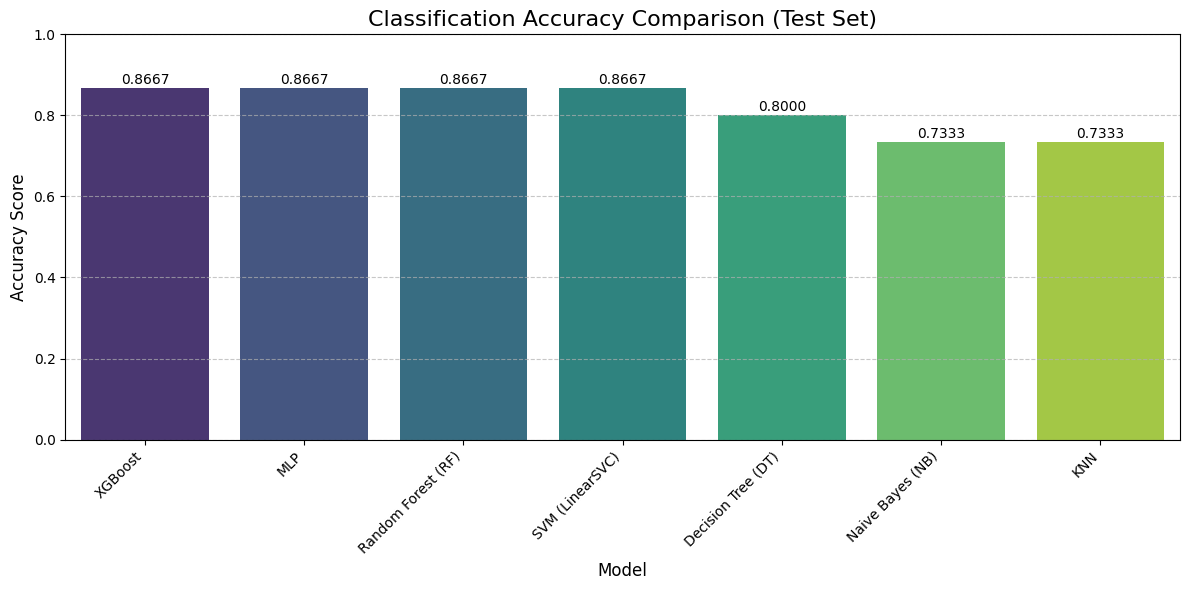

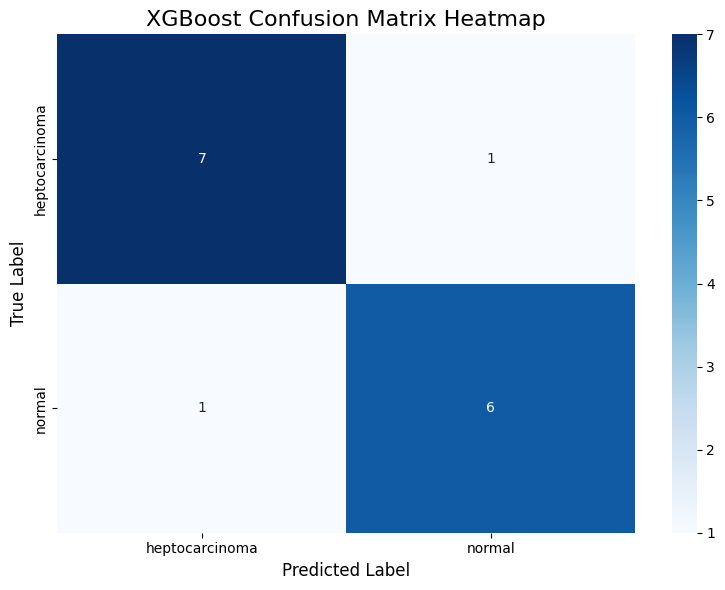

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, adjusted_rand_score, classification_report
import time

# Supervised Classifiers
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
# XGBoost requires separate installation in some environments
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print("WARNING: XGBoost not installed. Skipping XGBoost model.")
    XGB_AVAILABLE = False


# ==============================================================================
# 1. LOAD DATA & PREPROCESSING
# ==============================================================================

file_path = "/content/drive/MyDrive/Liver_GSE22405.csv"
df = pd.read_csv(file_path)

X = df.drop(columns=['samples', 'type'])
y_raw = df['type']

le = LabelEncoder()
y = le.fit_transform(y_raw)
n_clusters = len(le.classes_)
class_labels = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)


# ==============================================================================
# 2. MODEL TRAINING & PERFORMANCE COLLECTION
# ==============================================================================

models = {
    "SVM (LinearSVC)": LinearSVC(random_state=42, dual=False, max_iter=10000),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest (RF)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes (NB)": GaussianNB(),
    "Decision Tree (DT)": DecisionTreeClassifier(random_state=42)
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_estimators=100
    )


performance = {}
y_pred_rf = None

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    end_time = time.time()

    acc = accuracy_score(y_test, y_pred)
    performance[name] = acc

    # Store prediction for Random Forest (or XGBoost if available) for the heatmap
    if name == "Random Forest (RF)":
        y_pred_rf = y_pred
    elif name == "XGBoost":
        # If XGBoost is available, use it for the detailed report and heatmap
        print(f"\n--- XGBoost Classification Report (Performance Metrics) ---")
        print(classification_report(y_test, y_pred, target_names=class_labels, zero_division=0))
        y_pred_xgb = y_pred


# ==============================================================================
# 3. VISUALIZATIONS (GRAPH & HEATMAP)
# ==============================================================================

# --- 3.1. PERFORMANCE COMPARISON GRAPH (Bar Chart) ---
names = list(performance.keys())
scores = list(performance.values())

# Sort models by performance
sorted_indices = np.argsort(scores)[::-1]
names_sorted = [names[i] for i in sorted_indices]
scores_sorted = [scores[i] for i in sorted_indices]

plt.figure(figsize=(12, 6))
sns.barplot(x=names_sorted, y=scores_sorted, palette="viridis")
plt.ylim(0, 1.0)
plt.title('Classification Accuracy Comparison (Test Set)', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, score in enumerate(scores_sorted):
    plt.text(i, score + 0.01, f'{score:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_performance_comparison.png')


# --- 3.2. CONFUSION MATRIX HEATMAP ---
# Use Random Forest predictions since XGBoost may require installation
if y_pred_rf is not None:
    model_name = "Random Forest"
    cm_pred = y_pred_rf

    # If XGBoost was successfully run, prioritize its heatmap
    if 'y_pred_xgb' in locals():
        model_name = "XGBoost"
        cm_pred = y_pred_xgb

    cm = confusion_matrix(y_test, cm_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.title(f'{model_name} Confusion Matrix Heatmap', fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix_heatmap.png')

print("\nCode execution complete. Generated plots for model comparison and a confusion matrix heatmap.")